# Chapter 3: Underwater Image Dataset Profiling & Visual Analysis

## 3.1 Objective
Before deploying enhancement algorithms, we must mathematically profile the optical degradation present in the raw UIEB dataset. 

This notebook extracts four fundamental optical metrics:
1. **Turbidity/Blur:** Measured via Laplacian Variance.
2. **Spectral Absorption (Depth):** Measured by Red, Green, and Blue channel distributions.
3. **Illumination:** Measured by grayscale mean.
4. **Surface Refraction (Highlights):** Measured by the ratio of overexposed pixels, indicating sunlight caustics or water surface reflections.

---

## 3.2 Multi-Label Categorization Logic
Real-world underwater environments rarely suffer from a single type of degradation. For example, a deep-sea trench can be both dark (Low Illumination) and filled with marine snow (Turbid). To autonomously classify the dataset and route each image to the appropriate enhancement algorithm, we apply empirical thresholds based on underwater optical physics. 

### 1. Low Illumination
* **Threshold:** `Brightness < 50` *(Grayscale Mean)*
* **Optical Physics:** Indicates extreme underexposure, typically from deep-water trenches or insufficient ROV spotlighting. 
* **Intervention:** Global luminance stretching.

### 2. Turbid / High Haze
* **Threshold:** `Blur_Variance < 100` *(Laplacian Variance)*
* **Optical Physics:** Suspended particles cause "forward scattering," acting as a blur filter that destroys sharp, high-frequency edges.
* **Intervention:** Hybrid CLAHE and Unsharp Masking to restore edges and visibility.

### 3. Shallow (Sunlit / Caustics)
* **Threshold:** `Highlight_Ratio > 0.02` *(More than 2% of pixels > 220 brightness)*
* **Optical Physics:** Sunlight refracting through surface waves creates intense, localized bright spots (caustics) on the seafloor or surface. This prevents coastal green water from being misclassified as deep sea.
* **Intervention:** Mild Fusion-based enhancement to preserve natural lighting.

### 4. High Green Density (Algae)
* **Threshold:** `Green_Mean > Blue_Mean + 20` **AND** `Green_Mean > Red_Mean + 20`
* **Optical Physics:** Identifies coastal waters experiencing phytoplankton or algal blooms. These organic particles aggressively absorb both red and blue wavelengths, causing severe green dominance.
* **Intervention:** Channel-scaling algorithm to suppress the green wavelength prior to contrast enhancement.

### 5. Deep Sea (Severe Spectral Cast)
* **Threshold:** `Red_Mean < 40` **AND** (`Green_Mean > 80` **OR** `Blue_Mean > 80`) **AND** `Highlight_Ratio <= 0.02`
* **Optical Physics:** Red light is physically absorbed at depth. In the absence of sunlight caustics, this indicates true deep-sea spectral loss.
* **Intervention:** Targeted CIELAB color-shifting.

### 6. Standard / Moderate
* **Threshold:** Images that bypass all extreme limits above.
* **Optical Physics:** Captured in relatively clear water with adequate, uniform lighting.
* **Intervention:** Standard Multi-Scale Fusion.

If an image triggers none of the severe thresholds (1 through 5), it is tagged as **"Standard / Moderate"** and routed directly to mild fusion.

---

## 3.3 Visual Output
This notebook automatically generates three critical visualizations to justify our algorithmic choices:
* **Fig 1: Category Distribution Map** (Proving the need for an adaptive pipeline).
* **Fig 2: Spectral Scatter Plot** (Visualizing the severe loss of Red light at depth).
* **Fig 3: Turbidity Histogram** (Showing the density of backscatter/haze across the dataset).

In [1]:
import cv2
import numpy as np
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from collections import Counter

# Setup
RAW_PATH = "C:/Users/huiki/Desktop/FYP/data/raw/uieb/"
CSV_OUTPUT = "C:/Users/huiki/Desktop/FYP/data/processed/uieb_dataset_profile.csv"
VISUALS_OUT = "C:/Users/huiki/Desktop/FYP/data/processed/visuals/"
os.makedirs(VISUALS_OUT, exist_ok=True)

image_paths = glob.glob(os.path.join(RAW_PATH, "*.png")) + glob.glob(os.path.join(RAW_PATH, "*.jpg"))

profile_data = []
print(f"Extracting optical data from {len(image_paths)} images...")

for path in tqdm(image_paths, desc="Analyzing Optics"):
    filename = os.path.basename(path)
    img = cv2.imread(path)
    if img is None: continue
        
    b_mean, g_mean, r_mean = cv2.mean(img)[:3]
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    blur_score = cv2.Laplacian(gray, cv2.CV_64F).var()
    brightness = np.mean(gray)
    
    highlight_pixels = np.sum(gray > 220)
    total_pixels = gray.shape[0] * gray.shape[1]
    highlight_ratio = highlight_pixels / total_pixels
    
    # ==========================================
    # MULTI-LABEL CATEGORIZATION LOGIC
    # ==========================================
    tags = []
    
    if brightness < 50:
        tags.append("Low Illumination")
        
    if blur_score < 100:
        tags.append("Turbid / High Haze")
        
    if highlight_ratio > 0.02: 
        tags.append("Shallow (Sunlit / Caustics)")
        
    # [CALIBRATION]: If too many standard images get tagged as algae, increase '20' to '30'.
    if g_mean > b_mean + 20 and g_mean > r_mean + 20:
        tags.append("High Green Density (Algae)")
        
    # Prevent shallow sunlit water from falsely triggering deep sea
    if r_mean < 40 and (g_mean > 80 or b_mean > 80) and highlight_ratio <= 0.02:
        tags.append("Deep Sea (Severe Cast)")
        
    # If no severe degradation is found, label it as standard
    if len(tags) == 0:
        tags.append("Standard / Moderate")
        
    # Join the tags into a single string like "Low Illumination + Turbid"
    category_string = " + ".join(tags)
    # ==========================================
        
    profile_data.append({
        "Filename": filename, 
        "Red_Mean": round(r_mean, 2), 
        "Green_Mean": round(g_mean, 2), 
        "Blue_Mean": round(b_mean, 2), 
        "Blur_Variance": round(blur_score, 2), 
        "Brightness": round(brightness, 2), 
        "Highlight_Ratio": round(highlight_ratio, 4),
        "Category_Tags": category_string
    })

# Save to CSV
df = pd.DataFrame(profile_data)
df.to_csv(CSV_OUTPUT, index=False)
print("Data extraction complete. Master CSV updated. Generating visual graphs...")

Extracting optical data from 890 images...


Analyzing Optics: 100%|██████████████████████████████████████████████████████████████| 890/890 [00:22<00:00, 39.09it/s]

Data extraction complete. Master CSV updated. Generating visual graphs...


---
## 3.3 Visual Analysis of the UIEB Dataset

To mathematically justify our adaptive routing pipeline, we visualize the extracted optical data. 

* **Graph 1: Category Distribution Map (Multi-Label):** Quantifies the total instances of each degradation category. Because images can suffer from overlapping issues, the total count of issues will exceed the total number of images, proving the necessity of an adaptive, hybrid algorithm.
* **Graph 2: Spectral Scatter Plot:** Visualizes the relationship between Red and Green light attenuation. Deep-sea images cluster near the bottom (low red), while Algae-dominated images cluster in the extreme upper-left (massive green dominance, low red).
* **Graph 3: Turbidity Histogram:** Shows the density of backscatter. A vertical threshold line at 100 marks the boundary where physical model inversion becomes necessary to restore high-frequency structural edges.

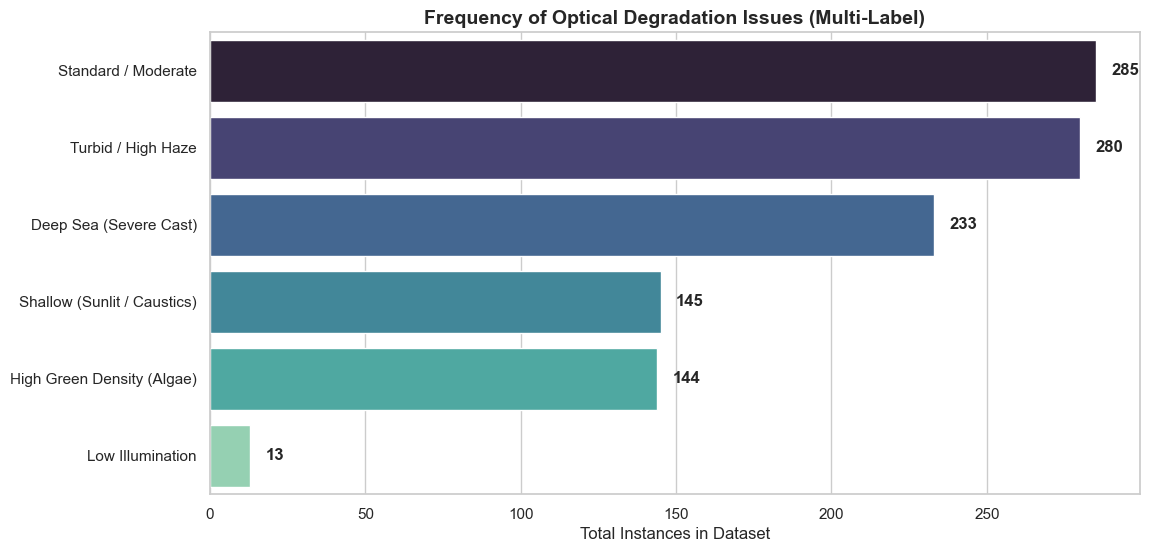

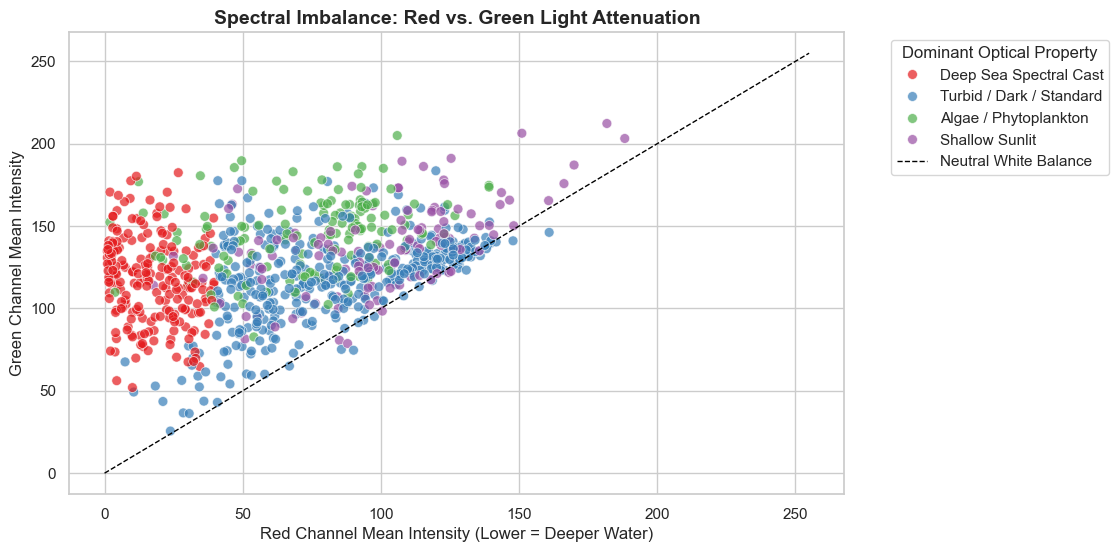

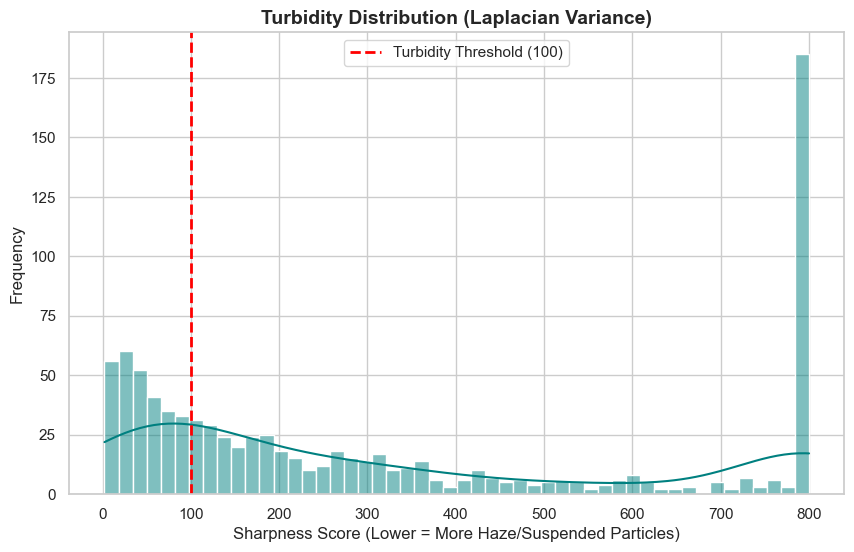

Visual analysis complete. All publication-ready graphs saved to: C:/Users/huiki/Desktop/FYP/data/processed/visuals/


In [2]:
# ==========================================
# Generate Multi-Label Visualization
# ==========================================
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

# --- Graph 1: Multi-Label Category Distribution ---
all_tags = []
for tag_string in df['Category_Tags']:
    all_tags.extend(tag_string.split(" + "))
    
tag_counts = Counter(all_tags)
tag_df = pd.DataFrame.from_dict(tag_counts, orient='index').reset_index()
tag_df.columns = ['Degradation Issue', 'Count']
tag_df = tag_df.sort_values(by='Count', ascending=False)

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=tag_df, y='Degradation Issue', x='Count', hue='Degradation Issue', palette='mako', legend=False)
plt.title("Frequency of Optical Degradation Issues (Multi-Label)", fontsize=14, fontweight='bold')
plt.xlabel("Total Instances in Dataset")
plt.ylabel("")

for p in ax.patches:
    width = p.get_width()
    plt.text(width + 5, p.get_y() + p.get_height() / 2, f'{int(width)}', 
             ha='left', va='center', fontweight='bold')

plt.savefig(os.path.join(VISUALS_OUT, "multi_label_distribution.png"), dpi=300, bbox_inches='tight')
plt.show()

# --- Graph 2: Spectral Absorption Scatter Plot ---
# Helper function to keep the scatter plot legend clean
def get_dominant_color_tag(tag_string):
    if "High Green Density" in tag_string: return "Algae / Phytoplankton"
    if "Deep Sea" in tag_string: return "Deep Sea Spectral Cast"
    if "Shallow" in tag_string: return "Shallow Sunlit"
    return "Turbid / Dark / Standard"

df['Plot_Hue'] = df['Category_Tags'].apply(get_dominant_color_tag)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Red_Mean', y='Green_Mean', hue='Plot_Hue', 
                palette='Set1', alpha=0.7, s=50)

plt.plot([0, 255], [0, 255], color='black', linestyle='--', linewidth=1, label='Neutral White Balance')
plt.title("Spectral Imbalance: Red vs. Green Light Attenuation", fontsize=14, fontweight='bold')
plt.xlabel("Red Channel Mean Intensity (Lower = Deeper Water)")
plt.ylabel("Green Channel Mean Intensity")
plt.legend(title='Dominant Optical Property', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.savefig(os.path.join(VISUALS_OUT, "spectral_scatter.png"), dpi=300, bbox_inches='tight')
plt.show()

# --- Graph 3: Turbidity / Blurriness Histogram ---
plt.figure(figsize=(10, 6))
sns.histplot(df['Blur_Variance'].clip(upper=800), bins=50, kde=True, color='teal')

plt.title("Turbidity Distribution (Laplacian Variance)", fontsize=14, fontweight='bold')
plt.xlabel("Sharpness Score (Lower = More Haze/Suspended Particles)")
plt.ylabel("Frequency")
plt.axvline(100, color='red', linestyle='--', linewidth=2, label='Turbidity Threshold (100)')
plt.legend()

plt.savefig(os.path.join(VISUALS_OUT, "turbidity_histogram.png"), dpi=300, bbox_inches='tight')
plt.show()

print(f"Visual analysis complete. All publication-ready graphs saved to: {VISUALS_OUT}")